**Outils - pandas**

*La bibliothèque `pandas` fournit des structures de données et des outils d'analyse de données hautes performances et faciles à utiliser. La structure de données principale est `DataFrame`, que vous pouvez considérer comme un tableau 2D en mémoire (comme une feuille de calcul, avec des noms de colonnes et des étiquettes de lignes). De nombreuses fonctionnalités disponibles dans Excel sont disponibles par programme, telles que la création de tableaux croisés dynamiques, le calcul de colonnes basées sur d'autres colonnes, le traçage de graphiques, etc. Vous pouvez également regrouper les lignes par valeur de colonne ou joindre des tables un peu comme dans SQL. Pandas est également excellent dans la gestion des séries chronologiques.*

Prérequis :
* NumPy – si vous n'êtes pas familier avec NumPy, nous vous recommandons de passer par le [NumPy tutorial](tools_numpy.ipynb) maintenant.

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/tools_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/tools_pandas.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Installation

Tout d’abord, importons `pandas`. Les gens l'importent généralement sous le nom `pd` :

In [1]:
import pandas as pd

# Objets `Series`
La bibliothèque `pandas` contient les structures de données utiles suivantes :
* Objets `Series`, dont nous allons parler maintenant. Un objet `Series` est un tableau 1D, similaire à une colonne dans une feuille de calcul (avec un nom de colonne et des étiquettes de ligne).
* Objets `DataFrame`. Il s'agit d'un tableau 2D, semblable à une feuille de calcul (avec des noms de colonnes et des étiquettes de lignes).
* Objets `Panel`. Vous pouvez voir un `Panel` comme un dictionnaire de `DataFrame`. Ceux-ci sont moins utilisés, nous n’en parlerons donc pas ici.

Error 500 (Server Error)!!1500.That’s an error.There was an error. Please try again later.That’s all we know.

In [2]:
s = pd.Series([2,-1,3,5])
s

0    2
1   -1
2    3
3    5
dtype: int64

Error 500 (Server Error)!!1500.That’s an error.There was an error. Please try again later.That’s all we know.

In [3]:
import numpy as np
np.exp(s)

0      7.389056
1      0.367879
2     20.085537
3    148.413159
dtype: float64

Les opérations arithmétiques sur `Series` sont également possibles, et elles s'appliquent *élément par élément*, tout comme pour les `ndarray` :

In [4]:
s + [1000,2000,3000,4000]

0    1002
1    1999
2    3003
3    4005
dtype: int64

Semblable à NumPy, si vous ajoutez un seul numéro à un `Series`, ce numéro est ajouté à tous les éléments du `Series`. C'est ce qu'on appelle la *diffusion* :

In [5]:
s + 1000

0    1002
1     999
2    1003
3    1005
dtype: int64

Il en va de même pour toutes les opérations binaires telles que `*` ou `/`, et même pour les opérations conditionnelles :

In [6]:
s < 0

0    False
1     True
2    False
3    False
dtype: bool

## Index des étiquettes
Chaque élément d'un objet `Series` possède un identifiant unique appelé *étiquette d'index*. Par défaut, il s'agit simplement du rang de l'élément dans le `Series` (à partir de `0`) mais vous pouvez également définir les étiquettes d'index manuellement :

In [7]:
s2 = pd.Series([68, 83, 112, 68], index=["alice", "bob", "charles", "darwin"])
s2

alice       68
bob         83
charles    112
darwin      68
dtype: int64

Vous pouvez ensuite utiliser le `Series` comme un `dict` :

In [8]:
s2["bob"]

83

Vous pouvez toujours accéder aux éléments par emplacement entier, comme dans un tableau normal :

In [9]:
s2[1]

83

Pour indiquer clairement lorsque vous accédez par étiquette ou par emplacement entier, il est recommandé de toujours utiliser l'attribut `loc` lors d'un accès par étiquette, et l'attribut `iloc` lors d'un accès par emplacement entier :

In [10]:
s2.loc["bob"]

83

In [11]:
s2.iloc[1]

83

Le découpage d'un `Series` découpe également les étiquettes d'index :

In [12]:
s2.iloc[1:3]

bob         83
charles    112
dtype: int64

Cela peut conduire à des résultats inattendus lors de l'utilisation des étiquettes numériques par défaut, alors soyez prudent :

In [13]:
surprise = pd.Series([1000, 1001, 1002, 1003])
surprise

0    1000
1    1001
2    1002
3    1003
dtype: int64

In [14]:
surprise_slice = surprise[2:]
surprise_slice

2    1002
3    1003
dtype: int64

Oh, regarde ! Le premier élément porte l’étiquette d’index `2`. L'élément avec le label d'index `0` est absent de la tranche :

In [15]:
try:
    surprise_slice[0]
except KeyError as e:
    print("Key error:", e)

Key error: 0


Mais n'oubliez pas que vous pouvez accéder aux éléments par emplacement entier à l'aide de l'attribut `iloc`. Cela illustre une autre raison pour laquelle il est toujours préférable d'utiliser `loc` et `iloc` pour accéder aux objets `Series` :

In [16]:
surprise_slice.iloc[0]

1002

## Init depuis `dict`
Vous pouvez créer un objet `Series` à partir d'un objet `dict`. Les clés seront utilisées comme étiquettes d'index :

In [17]:
weights = {"alice": 68, "bob": 83, "colin": 86, "darwin": 68}
s3 = pd.Series(weights)
s3

alice     68
bob       83
colin     86
darwin    68
dtype: int64

Vous pouvez contrôler les éléments que vous souhaitez inclure dans le `Series` et dans quel ordre en spécifiant explicitement le `index` souhaité :

In [18]:
s4 = pd.Series(weights, index = ["colin", "alice"])
s4

colin    86
alice    68
dtype: int64

## Alignement automatique
Lorsqu'une opération implique plusieurs objets `Series`, `pandas` aligne automatiquement les éléments en faisant correspondre les étiquettes d'index.

In [19]:
print(s2.keys())
print(s3.keys())

s2 + s3

Index(['alice', 'bob', 'charles', 'darwin'], dtype='object')
Index(['alice', 'bob', 'colin', 'darwin'], dtype='object')


alice      136.0
bob        166.0
charles      NaN
colin        NaN
darwin     136.0
dtype: float64

Le `Series` résultant contient l’union des étiquettes d’index de `s2` et `s3`. Étant donné que `"colin"` est absent de `s2` et que `"charles"` est absent de `s3`, ces éléments ont une valeur de résultat `NaN` (c'est-à-dire que Not-a-Number signifie *manquant*).

L'alignement automatique est très pratique lorsque vous travaillez avec des données pouvant provenir de diverses sources avec une structure variable et des éléments manquants. Mais si vous oubliez de définir les bonnes étiquettes d’index, vous pouvez obtenir des résultats surprenants :

In [20]:
s5 = pd.Series([1000,1000,1000,1000])
print("s2 =", s2.values)
print("s5 =", s5.values)

s2 + s5

s2 = [ 68  83 112  68]
s5 = [1000 1000 1000 1000]


alice     NaN
bob       NaN
charles   NaN
darwin    NaN
0         NaN
1         NaN
2         NaN
3         NaN
dtype: float64

Les pandas n'ont pas pu aligner le `Series`, car leurs étiquettes ne correspondent pas du tout, d'où le résultat complet `NaN`.

## Init avec un scalaire
Vous pouvez également initialiser un objet `Series` à l'aide d'un scalaire et d'une liste d'étiquettes d'index : tous les éléments seront définis sur le scalaire.

In [21]:
meaning = pd.Series(42, ["life", "universe", "everything"])
meaning

life          42
universe      42
everything    42
dtype: int64

## `Series` nom
Un `Series` peut avoir un `name` :

In [22]:
s6 = pd.Series([83, 68], index=["bob", "alice"], name="weights")
s6

bob      83
alice    68
Name: weights, dtype: int64

## Tracer un `Series`
Pandas facilite le tracé des données `Series` à l'aide de matplotlib (pour plus de détails sur matplotlib, consultez le [matplotlib tutorial](tools_matplotlib.ipynb)). Importez simplement matplotlib et appelez la méthode `plot()` :

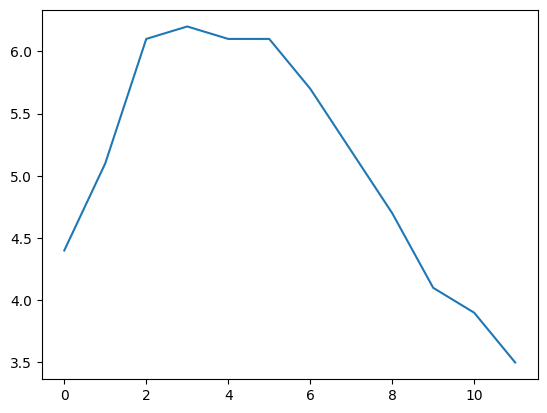

In [23]:
import matplotlib.pyplot as plt
temperatures = [4.4,5.1,6.1,6.2,6.1,6.1,5.7,5.2,4.7,4.1,3.9,3.5]
s7 = pd.Series(temperatures, name="Temperature")
s7.plot()
plt.show()

Il existe *de nombreuses* options pour tracer vos données. Il n'est pas nécessaire de tous les lister ici : si vous avez besoin d'un type particulier de tracé (histogrammes, camemberts, etc.), recherchez-le simplement dans l'excellente section [Visualization](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html) de la documentation de pandas, et regardez l'exemple de code.

# Temps de traitement
De nombreux ensembles de données ont des horodatages, et pandas est formidable pour manipuler de telles données :
* il peut représenter des périodes (telles que 2016T3) et des fréquences (telles que "mensuel"),
* il peut convertir les périodes en horodatages réels, et *vice versa*,
* il peut rééchantillonner les données et agréger les valeurs comme vous le souhaitez,
* il peut gérer les fuseaux horaires.

## Plage de temps
Commençons par créer une série chronologique à l'aide de `pd.date_range()`. Il renvoie un `DatetimeIndex` contenant une date/heure par heure pendant 12 heures à partir du 29 octobre 2016 à 17h30.

In [24]:
dates = pd.date_range('2016/10/29 5:30pm', periods=12, freq='h')
dates

DatetimeIndex(['2016-10-29 17:30:00', '2016-10-29 18:30:00',
               '2016-10-29 19:30:00', '2016-10-29 20:30:00',
               '2016-10-29 21:30:00', '2016-10-29 22:30:00',
               '2016-10-29 23:30:00', '2016-10-30 00:30:00',
               '2016-10-30 01:30:00', '2016-10-30 02:30:00',
               '2016-10-30 03:30:00', '2016-10-30 04:30:00'],
              dtype='datetime64[ns]', freq='H')

Ce `DatetimeIndex` peut être utilisé comme index dans un `Series` :

In [25]:
temp_series = pd.Series(temperatures, dates)
temp_series

2016-10-29 17:30:00    4.4
2016-10-29 18:30:00    5.1
2016-10-29 19:30:00    6.1
2016-10-29 20:30:00    6.2
2016-10-29 21:30:00    6.1
2016-10-29 22:30:00    6.1
2016-10-29 23:30:00    5.7
2016-10-30 00:30:00    5.2
2016-10-30 01:30:00    4.7
2016-10-30 02:30:00    4.1
2016-10-30 03:30:00    3.9
2016-10-30 04:30:00    3.5
Freq: H, dtype: float64

Traçons cette série :

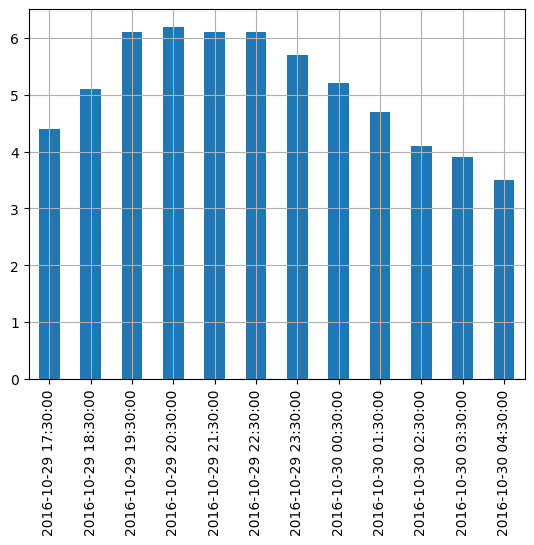

In [26]:
temp_series.plot(kind="bar")

plt.grid(True)
plt.show()

## Rééchantillonnage
Pandas nous permet de rééchantillonner une série temporelle très simplement. Appelez simplement la méthode `resample()` et spécifiez une nouvelle fréquence :

In [27]:
temp_series_freq_2H = temp_series.resample("2H")
temp_series_freq_2H

L'opération de rééchantillonnage est en fait une opération différée, c'est pourquoi nous n'avons pas obtenu un objet `Series`, mais un objet `DatetimeIndexResampler` à la place. Pour effectuer réellement l’opération de rééchantillonnage, nous pouvons simplement appeler la méthode `mean()`. Pandas calculera la moyenne de chaque paire d'heures consécutives :

In [28]:
temp_series_freq_2H = temp_series_freq_2H.mean()

Traçons le résultat :

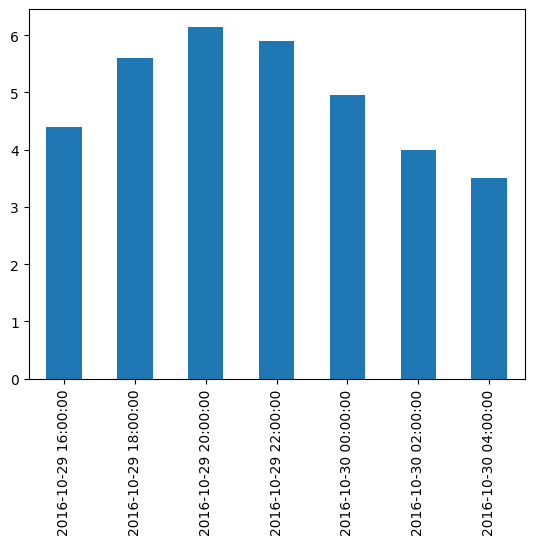

In [29]:
temp_series_freq_2H.plot(kind="bar")
plt.show()

Notez comment les valeurs ont été automatiquement regroupées en périodes de 2 heures. Si nous regardons la période 18h-20h, par exemple, nous avions une valeur de `5.1` à 18h30 et `6.1` à 19h30. Après rééchantillonnage, nous n'avons qu'une seule valeur de `5.6`, qui est la moyenne de `5.1` et `6.1`. Plutôt que de calculer la moyenne, on aurait pu utiliser n'importe quelle autre fonction d'agrégation, par exemple on peut décider de garder la valeur minimale de chaque période :

In [30]:
temp_series_freq_2H = temp_series.resample("2H").min()
temp_series_freq_2H

2016-10-29 16:00:00    4.4
2016-10-29 18:00:00    5.1
2016-10-29 20:00:00    6.1
2016-10-29 22:00:00    5.7
2016-10-30 00:00:00    4.7
2016-10-30 02:00:00    3.9
2016-10-30 04:00:00    3.5
Freq: 2H, dtype: float64

Ou, de manière équivalente, nous pourrions utiliser la méthode `apply()` à la place :

In [31]:
temp_series_freq_2H = temp_series.resample("2H").apply(np.min)
temp_series_freq_2H

2016-10-29 16:00:00    4.4
2016-10-29 18:00:00    5.1
2016-10-29 20:00:00    6.1
2016-10-29 22:00:00    5.7
2016-10-30 00:00:00    4.7
2016-10-30 02:00:00    3.9
2016-10-30 04:00:00    3.5
Freq: 2H, dtype: float64

## Suréchantillonnage et interpolation
C'était un exemple de sous-échantillonnage. Nous pouvons également suréchantillonner (c'est-à-dire augmenter la fréquence), mais cela créera des trous dans nos données :

In [32]:
temp_series_freq_15min = temp_series.resample("15Min").mean()
temp_series_freq_15min.head(n=10) # `head` displays the top n values

2016-10-29 17:30:00    4.4
2016-10-29 17:45:00    NaN
2016-10-29 18:00:00    NaN
2016-10-29 18:15:00    NaN
2016-10-29 18:30:00    5.1
2016-10-29 18:45:00    NaN
2016-10-29 19:00:00    NaN
2016-10-29 19:15:00    NaN
2016-10-29 19:30:00    6.1
2016-10-29 19:45:00    NaN
Freq: 15T, dtype: float64

Une solution consiste à combler les lacunes par interpolation. Nous appelons simplement la méthode `interpolate()`. La valeur par défaut est d'utiliser l'interpolation linéaire, mais nous pouvons également sélectionner une autre méthode, telle que l'interpolation cubique :

In [33]:
temp_series_freq_15min = temp_series.resample("15Min").interpolate(method="cubic")
temp_series_freq_15min.head(n=10)

2016-10-29 17:30:00    4.400000
2016-10-29 17:45:00    4.452911
2016-10-29 18:00:00    4.605113
2016-10-29 18:15:00    4.829758
2016-10-29 18:30:00    5.100000
2016-10-29 18:45:00    5.388992
2016-10-29 19:00:00    5.669887
2016-10-29 19:15:00    5.915839
2016-10-29 19:30:00    6.100000
2016-10-29 19:45:00    6.203621
Freq: 15T, dtype: float64

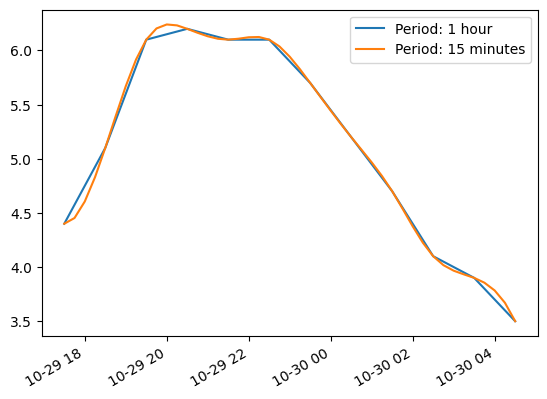

In [34]:
temp_series.plot(label="Period: 1 hour")
temp_series_freq_15min.plot(label="Period: 15 minutes")
plt.legend()
plt.show()

## Fuseaux horaires
Par défaut, les dates et heures sont *naïves* : elles ne connaissent pas les fuseaux horaires, donc 2016-10-30 02:30 peut signifier le 30 octobre 2016 à 2h30 du matin à Paris ou à New York. Nous pouvons *conscient* du fuseau horaire datetime en appelant la méthode `tz_localize()` :

In [35]:
temp_series_ny = temp_series.tz_localize("America/New_York")
temp_series_ny

2016-10-29 17:30:00-04:00    4.4
2016-10-29 18:30:00-04:00    5.1
2016-10-29 19:30:00-04:00    6.1
2016-10-29 20:30:00-04:00    6.2
2016-10-29 21:30:00-04:00    6.1
2016-10-29 22:30:00-04:00    6.1
2016-10-29 23:30:00-04:00    5.7
2016-10-30 00:30:00-04:00    5.2
2016-10-30 01:30:00-04:00    4.7
2016-10-30 02:30:00-04:00    4.1
2016-10-30 03:30:00-04:00    3.9
2016-10-30 04:30:00-04:00    3.5
dtype: float64

Notez que `-04:00` est désormais ajouté à toutes les dates et heures. Cela signifie que ces dates et heures font référence à [UTC](https://en.wikipedia.org/wiki/Coordinated_Universal_Time) - 4 heures.

Nous pouvons convertir ces dates-heures en heure de Paris comme ceci :

In [36]:
temp_series_paris = temp_series_ny.tz_convert("Europe/Paris")
temp_series_paris

2016-10-29 23:30:00+02:00    4.4
2016-10-30 00:30:00+02:00    5.1
2016-10-30 01:30:00+02:00    6.1
2016-10-30 02:30:00+02:00    6.2
2016-10-30 02:30:00+01:00    6.1
2016-10-30 03:30:00+01:00    6.1
2016-10-30 04:30:00+01:00    5.7
2016-10-30 05:30:00+01:00    5.2
2016-10-30 06:30:00+01:00    4.7
2016-10-30 07:30:00+01:00    4.1
2016-10-30 08:30:00+01:00    3.9
2016-10-30 09:30:00+01:00    3.5
dtype: float64

Vous avez peut-être remarqué que le décalage UTC passe de `+02:00` à `+01:00` : en effet, la France passe à l'heure d'hiver à 3h du matin ce soir-là (l'heure remonte à 2h du matin). Notez que 2h30 du matin se produit deux fois ! Revenons à une représentation naïve (si vous enregistrez des données toutes les heures en utilisant l'heure locale, sans stocker le fuseau horaire, vous pourriez obtenir quelque chose comme ceci) :

In [37]:
temp_series_paris_naive = temp_series_paris.tz_localize(None)
temp_series_paris_naive

2016-10-29 23:30:00    4.4
2016-10-30 00:30:00    5.1
2016-10-30 01:30:00    6.1
2016-10-30 02:30:00    6.2
2016-10-30 02:30:00    6.1
2016-10-30 03:30:00    6.1
2016-10-30 04:30:00    5.7
2016-10-30 05:30:00    5.2
2016-10-30 06:30:00    4.7
2016-10-30 07:30:00    4.1
2016-10-30 08:30:00    3.9
2016-10-30 09:30:00    3.5
dtype: float64

Maintenant, `02:30` est vraiment ambigu. Si nous essayons de localiser ces dates/heures naïves sur le fuseau horaire de Paris, nous obtenons une erreur :

In [38]:
try:
    temp_series_paris_naive.tz_localize("Europe/Paris")
except Exception as e:
    print(type(e))
    print(e)

<class 'pytz.exceptions.AmbiguousTimeError'>
Cannot infer dst time from 2016-10-30 02:30:00, try using the 'ambiguous' argument


Heureusement, en utilisant l'argument `ambiguous`, nous pouvons demander aux pandas de déduire le bon DST (Daylight Saving Time) en fonction de l'ordre des horodatages ambigus :

In [39]:
temp_series_paris_naive.tz_localize("Europe/Paris", ambiguous="infer")

2016-10-29 23:30:00+02:00    4.4
2016-10-30 00:30:00+02:00    5.1
2016-10-30 01:30:00+02:00    6.1
2016-10-30 02:30:00+02:00    6.2
2016-10-30 02:30:00+01:00    6.1
2016-10-30 03:30:00+01:00    6.1
2016-10-30 04:30:00+01:00    5.7
2016-10-30 05:30:00+01:00    5.2
2016-10-30 06:30:00+01:00    4.7
2016-10-30 07:30:00+01:00    4.1
2016-10-30 08:30:00+01:00    3.9
2016-10-30 09:30:00+01:00    3.5
dtype: float64

## Périodes
La fonction `pd.period_range()` renvoie un `PeriodIndex` au lieu d'un `DatetimeIndex`. Par exemple, obtenons tous les trimestres de 2016 et 2017 :

In [40]:
quarters = pd.period_range('2016Q1', periods=8, freq='Q')
quarters

PeriodIndex(['2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2',
             '2017Q3', '2017Q4'],
            dtype='period[Q-DEC]')

L'ajout d'un nombre `N` à un `PeriodIndex` décale les périodes de `N` fois la fréquence de `PeriodIndex` :

In [41]:
quarters + 3

PeriodIndex(['2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1',
             '2018Q2', '2018Q3'],
            dtype='period[Q-DEC]')

La méthode `asfreq()` nous permet de changer la fréquence du `PeriodIndex`. Tous les délais sont allongés ou raccourcis en conséquence. Par exemple, convertissons toutes les périodes trimestrielles en périodes mensuelles (zoom avant) :

In [42]:
quarters.asfreq("M")

PeriodIndex(['2016-03', '2016-06', '2016-09', '2016-12', '2017-03', '2017-06',
             '2017-09', '2017-12'],
            dtype='period[M]')

Par défaut, le `asfreq` effectue un zoom sur la fin de chaque période. On peut plutôt lui dire de zoomer sur le début de chaque période :

In [43]:
quarters.asfreq("M", how="start")

PeriodIndex(['2016-01', '2016-04', '2016-07', '2016-10', '2017-01', '2017-04',
             '2017-07', '2017-10'],
            dtype='period[M]')

Et nous pouvons effectuer un zoom arrière :

In [44]:
quarters.asfreq("A")

PeriodIndex(['2016', '2016', '2016', '2016', '2017', '2017', '2017', '2017'], dtype='period[A-DEC]')

Bien entendu, nous pouvons créer un `Series` avec un `PeriodIndex` :

In [45]:
quarterly_revenue = pd.Series([300, 320, 290, 390, 320, 360, 310, 410], index=quarters)
quarterly_revenue

2016Q1    300
2016Q2    320
2016Q3    290
2016Q4    390
2017Q1    320
2017Q2    360
2017Q3    310
2017Q4    410
Freq: Q-DEC, dtype: int64

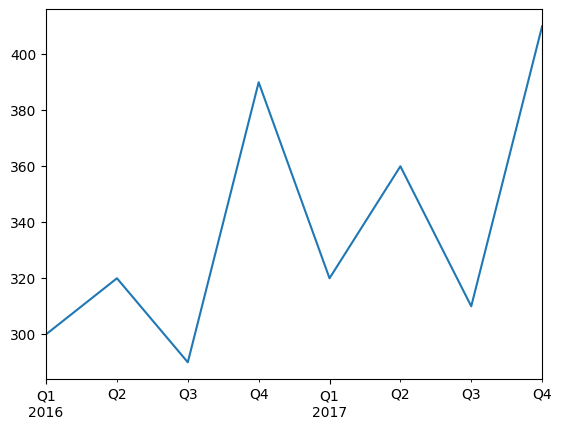

In [46]:
quarterly_revenue.plot(kind="line")
plt.show()

Nous pouvons convertir des périodes en horodatages en appelant `to_timestamp`. Par défaut, cela nous donnera le premier jour de chaque période, mais en définissant `how` et `freq`, nous pouvons obtenir la dernière heure de chaque période :

In [47]:
last_hours = quarterly_revenue.to_timestamp(how="end", freq="h")
last_hours

2016-03-31 23:59:59.999999999    300
2016-06-30 23:59:59.999999999    320
2016-09-30 23:59:59.999999999    290
2016-12-31 23:59:59.999999999    390
2017-03-31 23:59:59.999999999    320
2017-06-30 23:59:59.999999999    360
2017-09-30 23:59:59.999999999    310
2017-12-31 23:59:59.999999999    410
dtype: int64

Et revenons aux périodes en appelant `to_period` :

In [48]:
last_hours.to_period()

2016Q1    300
2016Q2    320
2016Q3    290
2016Q4    390
2017Q1    320
2017Q2    360
2017Q3    310
2017Q4    410
Freq: Q-DEC, dtype: int64

Pandas fournit également de nombreuses autres fonctions liées au temps que nous vous recommandons de consulter dans le [documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html). Pour vous mettre en appétit, voici une façon d'obtenir le dernier jour ouvrable de chaque mois en 2016, à 9h :

In [49]:
months_2016 = pd.period_range("2016", periods=12, freq="M")
one_day_after_last_days = months_2016.asfreq("D") + 1
last_bdays = one_day_after_last_days.to_timestamp() - pd.tseries.offsets.BDay()
last_bdays.to_period("H") + 9

PeriodIndex(['2016-01-29 09:00', '2016-02-29 09:00', '2016-03-31 09:00',
             '2016-04-29 09:00', '2016-05-31 09:00', '2016-06-30 09:00',
             '2016-07-29 09:00', '2016-08-31 09:00', '2016-09-30 09:00',
             '2016-10-31 09:00', '2016-11-30 09:00', '2016-12-30 09:00'],
            dtype='period[H]')

# Objets `DataFrame`
Un objet DataFrame représente une feuille de calcul, avec des valeurs de cellules, des noms de colonnes et des étiquettes d'index de lignes. Vous pouvez définir des expressions pour calculer des colonnes basées sur d'autres colonnes, créer des tableaux croisés dynamiques, regrouper des lignes, dessiner des graphiques, etc. Vous pouvez voir les `DataFrame` comme des dictionnaires de `Series`.

## Création d'un `DataFrame`
Vous pouvez créer un DataFrame en passant un dictionnaire d'objets `Series` :

In [50]:
people_dict = {
    "weight": pd.Series([68, 83, 112], index=["alice", "bob", "charles"]),
    "birthyear": pd.Series([1984, 1985, 1992], index=["bob", "alice", "charles"], name="year"),
    "children": pd.Series([0, 3], index=["charles", "bob"]),
    "hobby": pd.Series(["Biking", "Dancing"], index=["alice", "bob"]),
}
people = pd.DataFrame(people_dict)
people

,weight,birthyear,children,hobby
alice,68,1985,NaN,Biking
bob,83,1984,3.0,Dancing
charles,112,1992,0.0,NaN


Quelques points à noter :
* les `Series` étaient automatiquement alignés en fonction de leur index,
* les valeurs manquantes sont représentées par `NaN`,
* Les noms `Series` sont ignorés (le nom `"year"` a été supprimé),
* Les `DataFrame` s'affichent bien dans les notebooks Jupyter, woohoo !

Vous pouvez accéder aux colonnes à peu près comme vous le souhaiteriez. Ils sont renvoyés sous forme d'objets `Series` :

In [51]:
people["birthyear"]

alice      1985
bob        1984
charles    1992
Name: birthyear, dtype: int64

Vous pouvez également obtenir plusieurs colonnes à la fois :

In [52]:
people[["birthyear", "hobby"]]

,birthyear,hobby
alice,1985,Biking
bob,1984,Dancing
charles,1992,NaN


Si vous transmettez une liste de colonnes et/ou d'étiquettes de lignes d'index au constructeur `DataFrame`, cela garantira que ces colonnes et/ou lignes existeront, dans cet ordre, et qu'aucune autre colonne/ligne n'existera. Par exemple:

In [53]:
d2 = pd.DataFrame(
        people_dict,
        columns=["birthyear", "weight", "height"],
        index=["bob", "alice", "eugene"]
     )
d2

,birthyear,weight,height
bob,1984.0,83.0,NaN
alice,1985.0,68.0,NaN
eugene,NaN,NaN,NaN


Un autre moyen pratique de créer un `DataFrame` consiste à transmettre toutes les valeurs au constructeur sous la forme d'un `ndarray` ou d'une liste de listes, et de spécifier séparément les noms de colonnes et les étiquettes d'index de ligne :

In [54]:
values = [
            [1985, np.nan, "Biking",   68],
            [1984, 3,      "Dancing",  83],
            [1992, 0,      np.nan,    112]
         ]
d3 = pd.DataFrame(
        values,
        columns=["birthyear", "children", "hobby", "weight"],
        index=["alice", "bob", "charles"]
     )
d3

,birthyear,children,hobby,weight
alice,1985,NaN,Biking,68
bob,1984,3.0,Dancing,83
charles,1992,0.0,NaN,112


Pour spécifier les valeurs manquantes, vous pouvez utiliser `np.nan` ou les tableaux masqués de NumPy :

In [55]:
masked_array = np.ma.asarray(values, dtype=object)
masked_array[(0, 2), (1, 2)] = np.ma.masked
d3 = pd.DataFrame(
        masked_array,
        columns=["birthyear", "children", "hobby", "weight"],
        index=["alice", "bob", "charles"]
     )
d3

,birthyear,children,hobby,weight
alice,1985,NaN,Biking,68
bob,1984,3,Dancing,83
charles,1992,0,NaN,112


Au lieu d'un objet `ndarray`, vous pouvez également transmettre un objet `DataFrame` :

In [56]:
d4 = pd.DataFrame(
         d3,
         columns=["hobby", "children"],
         index=["alice", "bob"]
     )
d4

,hobby,children
alice,Biking,NaN
bob,Dancing,3


Il est également possible de créer un `DataFrame` avec un dictionnaire (ou liste) de dictionnaires (ou listes) :

In [57]:
people = pd.DataFrame({
    "birthyear": {"alice": 1985, "bob": 1984, "charles": 1992},
    "hobby": {"alice": "Biking", "bob": "Dancing"},
    "weight": {"alice": 68, "bob": 83, "charles": 112},
    "children": {"bob": 3, "charles": 0}
})
people

,birthyear,hobby,weight,children
alice,1985,Biking,68,NaN
bob,1984,Dancing,83,3.0
charles,1992,NaN,112,0.0


## Multi-indexation
Si toutes les colonnes sont des tuples de même taille, elles sont alors considérées comme un multi-index. Il en va de même pour les étiquettes d’index de ligne. Par exemple:

In [58]:
d5 = pd.DataFrame(
  {
    ("public", "birthyear"):
        {("Paris","alice"): 1985, ("Paris","bob"): 1984, ("London","charles"): 1992},
    ("public", "hobby"):
        {("Paris","alice"): "Biking", ("Paris","bob"): "Dancing"},
    ("private", "weight"):
        {("Paris","alice"): 68, ("Paris","bob"): 83, ("London","charles"): 112},
    ("private", "children"):
        {("Paris", "alice"): np.nan, ("Paris","bob"): 3, ("London","charles"): 0}
  }
)
d5

public          private         
               birthyear    hobby  weight children
Paris  alice        1985   Biking      68      NaN
       bob          1984  Dancing      83      3.0
London charles      1992      NaN     112      0.0

Vous pouvez désormais obtenir un `DataFrame` contenant toutes les colonnes `"public"` très simplement :

In [59]:
d5["public"]

birthyear    hobby
Paris  alice         1985   Biking
       bob           1984  Dancing
London charles       1992      NaN

In [60]:
d5["public", "hobby"]  # Same result as d5["public"]["hobby"]

Paris   alice       Biking
        bob        Dancing
London  charles        NaN
Name: (public, hobby), dtype: object

## Supprimer un niveau
Regardons à nouveau `d5` :

In [61]:
d5

public          private         
               birthyear    hobby  weight children
Paris  alice        1985   Biking      68      NaN
       bob          1984  Dancing      83      3.0
London charles      1992      NaN     112      0.0

Il existe deux niveaux de colonnes et deux niveaux d'index. On peut supprimer un niveau de colonne en appelant `droplevel()` (il en va de même pour les indices) :

In [62]:
d5.columns = d5.columns.droplevel(level = 0)
d5

birthyear    hobby  weight  children
Paris  alice         1985   Biking      68       NaN
       bob           1984  Dancing      83       3.0
London charles       1992      NaN     112       0.0

## Transposition
Vous pouvez échanger des colonnes et des index à l'aide de l'attribut `T` :

In [63]:
d6 = d5.T
d6

Paris           London
            alice      bob charles
birthyear    1985     1984    1992
hobby      Biking  Dancing     NaN
weight         68       83     112
children      NaN      3.0     0.0

## Niveaux d'empilement et de dépilage
L’appel de la méthode `stack()` poussera le niveau de colonne le plus bas après l’index le plus bas :

In [64]:
d7 = d6.stack()
d7

London    Paris
birthyear alice      NaN     1985
          bob        NaN     1984
          charles   1992      NaN
hobby     alice      NaN   Biking
          bob        NaN  Dancing
weight    alice      NaN       68
          bob        NaN       83
          charles    112      NaN
children  bob        NaN      3.0
          charles    0.0      NaN

Notez que de nombreuses valeurs `NaN` sont apparues. Cela est logique car de nombreuses nouvelles combinaisons n'existaient pas auparavant (par exemple, il n'y avait pas de `bob` dans `London`).

L’appel de `unstack()` fera l’inverse, créant à nouveau de nombreuses valeurs `NaN`.

In [65]:
d8 = d7.unstack()
d8

London                Paris                 
           alice  bob charles   alice      bob charles
birthyear    NaN  NaN    1992    1985     1984     NaN
children     NaN  NaN     0.0     NaN      3.0     NaN
hobby        NaN  NaN     NaN  Biking  Dancing     NaN
weight       NaN  NaN     112      68       83     NaN

Si on appelle à nouveau `unstack`, on se retrouve avec un objet `Series` :

In [66]:
d9 = d8.unstack()
d9

London  alice    birthyear        NaN
                 children         NaN
                 hobby            NaN
                 weight           NaN
        bob      birthyear        NaN
                 children         NaN
                 hobby            NaN
                 weight           NaN
        charles  birthyear       1992
                 children         0.0
                 hobby            NaN
                 weight           112
Paris   alice    birthyear       1985
                 children         NaN
                 hobby         Biking
                 weight            68
        bob      birthyear       1984
                 children         3.0
                 hobby        Dancing
                 weight            83
        charles  birthyear        NaN
                 children         NaN
                 hobby            NaN
                 weight           NaN
dtype: object

Les méthodes `stack()` et `unstack()` vous permettent de sélectionner le `level` à empiler/dépiler. Vous pouvez même empiler/dépiler plusieurs niveaux à la fois :

In [67]:
d10 = d9.unstack(level = (0,1))
d10

London                Paris                 
           alice  bob charles   alice      bob charles
birthyear    NaN  NaN    1992    1985     1984     NaN
children     NaN  NaN     0.0     NaN      3.0     NaN
hobby        NaN  NaN     NaN  Biking  Dancing     NaN
weight       NaN  NaN     112      68       83     NaN

## La plupart des méthodes renvoient des copies modifiées
Comme vous l'avez peut-être remarqué, les méthodes `stack()` et `unstack()` ne modifient pas l'objet sur lequel elles sont appelées. Au lieu de cela, ils travaillent sur une copie et renvoient cette copie. Cela est vrai pour la plupart des méthodes utilisées chez les pandas.

## Accès aux lignes
Revenons au `people` `DataFrame` :

In [68]:
people

,birthyear,hobby,weight,children
alice,1985,Biking,68,NaN
bob,1984,Dancing,83,3.0
charles,1992,NaN,112,0.0


L'attribut `loc` vous permet d'accéder aux lignes plutôt qu'aux colonnes. Le résultat est un objet `Series` dans lequel les noms de colonnes `DataFrame` sont mappés aux étiquettes d'index de ligne :

In [69]:
people.loc["charles"]

birthyear    1992
hobby         NaN
weight        112
children      0.0
Name: charles, dtype: object

Vous pouvez également accéder aux lignes par emplacement entier à l'aide de l'attribut `iloc` :

In [70]:
people.iloc[2]

birthyear    1992
hobby         NaN
weight        112
children      0.0
Name: charles, dtype: object

Vous pouvez également obtenir une tranche de lignes, et cela renvoie un objet `DataFrame` :

In [71]:
people.iloc[1:3]

,birthyear,hobby,weight,children
bob,1984,Dancing,83,3.0
charles,1992,NaN,112,0.0


Enfin, vous pouvez passer un tableau booléen pour obtenir les lignes correspondantes :

In [72]:
people[np.array([True, False, True])]

,birthyear,hobby,weight,children
alice,1985,Biking,68,NaN
charles,1992,NaN,112,0.0


Ceci est plus utile lorsqu'il est combiné avec des expressions booléennes :

In [73]:
people[people["birthyear"] < 1990]

,birthyear,hobby,weight,children
alice,1985,Biking,68,NaN
bob,1984,Dancing,83,3.0


## Ajout et suppression de colonnes
Vous pouvez généralement traiter les objets `DataFrame` comme des dictionnaires de `Series`, donc ce qui suit fonctionne correctement :

In [74]:
people

,birthyear,hobby,weight,children
alice,1985,Biking,68,NaN
bob,1984,Dancing,83,3.0
charles,1992,NaN,112,0.0


In [75]:
people["age"] = 2018 - people["birthyear"]  # adds a new column "age"
people["over 30"] = people["age"] > 30      # adds another column "over 30"
birthyears = people.pop("birthyear")
del people["children"]

people

,hobby,weight,age,over 30
alice,Biking,68,33,True
bob,Dancing,83,34,True
charles,NaN,112,26,False


In [76]:
birthyears

alice      1985
bob        1984
charles    1992
Name: birthyear, dtype: int64

Lorsque vous ajoutez une nouvelle colonne, elle doit avoir le même nombre de lignes. Les lignes manquantes sont remplies avec NaN et les lignes supplémentaires sont ignorées :

In [77]:
people["pets"] = pd.Series({"bob": 0, "charles": 5, "eugene": 1})  # alice is missing, eugene is ignored
people

,hobby,weight,age,over 30,pets
alice,Biking,68,33,True,NaN
bob,Dancing,83,34,True,0.0
charles,NaN,112,26,False,5.0


Lors de l'ajout d'une nouvelle colonne, elle est ajoutée à la fin (à droite) par défaut. Vous pouvez également insérer une colonne n'importe où ailleurs à l'aide de la méthode `insert()` :

In [78]:
people.insert(1, "height", [172, 181, 185])
people

,hobby,height,weight,age,over 30,pets
alice,Biking,172,68,33,True,NaN
bob,Dancing,181,83,34,True,0.0
charles,NaN,185,112,26,False,5.0


## Attribution de nouvelles colonnes
Vous pouvez également créer de nouvelles colonnes en appelant la méthode `assign()`. Notez que cela renvoie un nouvel objet `DataFrame`, l'original n'est pas modifié :

In [79]:
people.assign(
    body_mass_index = people["weight"] / (people["height"] / 100) ** 2,
    has_pets = people["pets"] > 0
)

,hobby,height,weight,age,over 30,pets,body_mass_index,has_pets
alice,Biking,172,68,33,True,NaN,22.985398,False
bob,Dancing,181,83,34,True,0.0,25.335002,False
charles,NaN,185,112,26,False,5.0,32.724617,True


Notez que vous ne pouvez pas accéder aux colonnes créées au sein de la même affectation :

In [80]:
try:
    people.assign(
        body_mass_index = people["weight"] / (people["height"] / 100) ** 2,
        overweight = people["body_mass_index"] > 25
    )
except KeyError as e:
    print("Key error:", e)

Key error: 'body_mass_index'


La solution est de diviser cette mission en deux missions consécutives :

In [81]:
d6 = people.assign(body_mass_index = people["weight"] / (people["height"] / 100) ** 2)
d6.assign(overweight = d6["body_mass_index"] > 25)

,hobby,height,weight,age,over 30,pets,body_mass_index,overweight
alice,Biking,172,68,33,True,NaN,22.985398,False
bob,Dancing,181,83,34,True,0.0,25.335002,True
charles,NaN,185,112,26,False,5.0,32.724617,True


Devoir créer une variable temporaire `d6` n'est pas très pratique. Vous souhaiterez peut-être simplement enchaîner les appels d'affectation, mais cela ne fonctionne pas car l'objet `people` n'est pas réellement modifié par la première affectation :

In [82]:
try:
    (people
         .assign(body_mass_index = people["weight"] / (people["height"] / 100) ** 2)
         .assign(overweight = people["body_mass_index"] > 25)
    )
except KeyError as e:
    print("Key error:", e)

Key error: 'body_mass_index'


Mais n’ayez crainte, il existe une solution simple. Vous pouvez passer une fonction à la méthode `assign()` (généralement une fonction `lambda`), et cette fonction sera appelée avec le `DataFrame` en paramètre :

In [83]:
(people
     .assign(body_mass_index = lambda df: df["weight"] / (df["height"] / 100) ** 2)
     .assign(overweight = lambda df: df["body_mass_index"] > 25)
)

,hobby,height,weight,age,over 30,pets,body_mass_index,overweight
alice,Biking,172,68,33,True,NaN,22.985398,False
bob,Dancing,181,83,34,True,0.0,25.335002,True
charles,NaN,185,112,26,False,5.0,32.724617,True


Problème résolu !

## Évaluer une expression
Une fonctionnalité intéressante prise en charge par les pandas est l'évaluation des expressions. Il s'appuie sur la bibliothèque `numexpr` qui doit être installée.

In [84]:
people.eval("weight / (height/100) ** 2 > 25")

alice      False
bob         True
charles     True
dtype: bool

Les expressions d'affectation sont également prises en charge. Définissons `inplace=True` pour modifier directement le `DataFrame` plutôt que d'obtenir une copie modifiée :

In [85]:
people.eval("body_mass_index = weight / (height/100) ** 2", inplace=True)
people

,hobby,height,weight,age,over 30,pets,body_mass_index
alice,Biking,172,68,33,True,NaN,22.985398
bob,Dancing,181,83,34,True,0.0,25.335002
charles,NaN,185,112,26,False,5.0,32.724617


Vous pouvez utiliser une variable locale ou globale dans une expression en la préfixant par `'@'` :

In [86]:
overweight_threshold = 30
people.eval("overweight = body_mass_index > @overweight_threshold", inplace=True)
people

ValueError: ignored

## Interrogation d'un `DataFrame`
La méthode `query()` vous permet de filtrer un `DataFrame` en fonction d'une expression de requête :

In [ ]:
people.query("age > 30 and pets == 0")

## Tri d'un `DataFrame`
Vous pouvez trier un `DataFrame` en appelant sa méthode `sort_index`. Par défaut, il trie les lignes par leur étiquette d'index, par ordre croissant, mais inversons l'ordre :

In [ ]:
people.sort_index(ascending=False)

Notez que `sort_index` a renvoyé une *copie* triée du `DataFrame`. Pour modifier directement `people`, nous pouvons définir l'argument `inplace` sur `True`. De plus, nous pouvons trier les colonnes au lieu des lignes en définissant `axis=1` :

In [ ]:
people.sort_index(axis=1, inplace=True)
people

Pour trier le `DataFrame` par les valeurs au lieu des étiquettes, nous pouvons utiliser `sort_values` et spécifier la colonne sur laquelle trier :

In [ ]:
people.sort_values(by="age", inplace=True)
people

## Tracer un `DataFrame`
Tout comme pour `Series`, pandas permet de dessiner facilement de jolis graphiques basés sur un `DataFrame`.

Par exemple, il est simple de créer un tracé linéaire à partir des données d'un `DataFrame` en appelant sa méthode `plot` :

In [ ]:
people.sort_values(by="body_mass_index", inplace=True)
people.plot(kind="line", x="body_mass_index", y=["height", "weight"])
plt.show()

Vous pouvez transmettre des arguments supplémentaires pris en charge par les fonctions de matplotlib. Par exemple, nous pouvons créer un nuage de points et lui transmettre une liste de tailles en utilisant l'argument `s` de la fonction `scatter()` de matplotlib :

In [ ]:
people.plot(kind="scatter", x="height", y="weight", s=[40, 120, 200])
plt.show()

Encore une fois, il y a beaucoup trop d'options à lister ici : la meilleure option est de faire défiler la page [Visualization](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html) dans la documentation de pandas, de trouver l'intrigue qui vous intéresse et de regarder l'exemple de code.

## Opérations sur les `DataFrame`
Bien que les `DataFrame` n'essaient pas d'imiter les tableaux NumPy, il existe quelques similitudes. Créons un `DataFrame` pour démontrer ceci :

In [ ]:
grades_array = np.array([[8, 8, 9], [10, 9, 9], [4, 8, 2], [9, 10, 10]])
grades = pd.DataFrame(grades_array, columns=["sep", "oct", "nov"], index=["alice", "bob", "charles", "darwin"])
grades

Vous pouvez appliquer les fonctions mathématiques NumPy sur un `DataFrame` : la fonction est appliquée à toutes les valeurs :

In [ ]:
np.sqrt(grades)

De même, l’ajout d’une seule valeur à un `DataFrame` ajoutera cette valeur à tous les éléments du `DataFrame`. C'est ce qu'on appelle la *diffusion* :

In [ ]:
grades + 1

Bien entendu, il en va de même pour toutes les autres opérations binaires, y compris les opérations arithmétiques (`*`,`/`,`**`...) et conditionnelles (`>`, `==`...) :

In [ ]:
grades >= 5

Les opérations d'agrégation, telles que le calcul du `max`, du `sum` ou du `mean` d'un `DataFrame`, s'appliquent à chaque colonne et vous récupérez un objet `Series` :

In [ ]:
grades.mean()

La méthode `all` est également une opération d'agrégation : elle vérifie si toutes les valeurs sont `True` ou non. Voyons au cours desquels tous les élèves ont obtenu une note supérieure à `5` :

In [ ]:
(grades > 5).all()

La plupart de ces fonctions prennent un paramètre facultatif `axis` qui vous permet de spécifier le long de quel axe du `DataFrame` vous souhaitez que l'opération soit exécutée. La valeur par défaut est `axis=0`, ce qui signifie que l'opération est exécutée verticalement (sur chaque colonne). Vous pouvez configurer `axis=1` pour exécuter l'opération horizontalement (sur chaque ligne). Par exemple, découvrons quels élèves ont obtenu toutes des notes supérieures à `5` :

In [ ]:
(grades > 5).all(axis=1)

La méthode `any` renvoie `True` si une valeur est True. Voyons qui a obtenu au moins une 10e année :

In [ ]:
(grades == 10).any(axis=1)

Si vous ajoutez un objet `Series` à un `DataFrame` (ou exécutez toute autre opération binaire), pandas tente de diffuser l'opération sur toutes les *lignes* du `DataFrame`. Cela ne fonctionne que si le `Series` a la même taille que les lignes `DataFrame`s. Par exemple, soustrayons le `mean` du `DataFrame` (un objet `Series`) du `DataFrame` :

In [ ]:
grades - grades.mean()  # equivalent to: grades - [7.75, 8.75, 7.50]

Nous avons soustrait `7.75` de toutes les notes de septembre, `8.75` des notes d'octobre et `7.50` des notes de novembre. Cela équivaut à soustraire ce `DataFrame` :

In [ ]:
pd.DataFrame([[7.75, 8.75, 7.50]]*4, index=grades.index, columns=grades.columns)

Si vous souhaitez soustraire la moyenne globale de chaque note, voici une façon de procéder :

In [ ]:
grades - grades.values.mean() # subtracts the global mean (8.00) from all grades

## Alignement automatique
Semblable à `Series`, lorsqu'il fonctionne sur plusieurs `DataFrame`, les pandas les aligne automatiquement par étiquette d'index de ligne, mais également par noms de colonnes. Créons un `DataFrame` avec des points bonus pour chaque personne d'octobre à décembre :

In [ ]:
bonus_array = np.array([[0, np.nan, 2], [np.nan, 1, 0], [0, 1, 0], [3, 3, 0]])
bonus_points = pd.DataFrame(bonus_array, columns=["oct", "nov", "dec"], index=["bob", "colin", "darwin", "charles"])
bonus_points

In [ ]:
grades + bonus_points

On dirait que l'ajout a fonctionné dans certains cas, mais beaucoup trop d'éléments sont maintenant vides. En effet, lors de l'alignement des `DataFrame`, certaines colonnes et lignes n'étaient présentes que d'un côté et ont donc été considérées comme manquantes de l'autre côté (`NaN`). Ensuite, l'ajout de `NaN` à un nombre donne `NaN`, d'où le résultat.

## Gestion des données manquantes
Traiter les données manquantes est une tâche fréquente lorsque l’on travaille avec des données réelles. Pandas propose quelques outils pour gérer les données manquantes.

Essayons de résoudre le problème ci-dessus. Par exemple, nous pouvons décider que les données manquantes doivent donner un zéro, au lieu de `NaN`. Nous pouvons remplacer toutes les valeurs `NaN` par n'importe quelle valeur en utilisant la méthode `fillna()` :

In [ ]:
(grades + bonus_points).fillna(0)

Il est cependant un peu injuste que nous remettions les notes à zéro en septembre. Peut-être devrions-nous décider que les notes manquantes sont des notes manquantes, mais les points bonus manquants devraient être remplacés par des zéros :

In [ ]:
fixed_bonus_points = bonus_points.fillna(0)
fixed_bonus_points.insert(0, "sep", 0)
fixed_bonus_points.loc["alice"] = 0
grades + fixed_bonus_points

C'est bien mieux : même si nous avons inventé certaines données, nous n'avons pas été trop injustes.

Une autre façon de gérer les données manquantes consiste à interpoler. Regardons à nouveau le `bonus_points` `DataFrame` :

In [ ]:
bonus_points

Appelons maintenant la méthode `interpolate`. Par défaut, il interpole verticalement (`axis=0`), disons-lui donc d'interpoler horizontalement (`axis=1`).

In [ ]:
bonus_points.interpolate(axis=1)

Bob avait 0 point bonus en octobre et 2 en décembre. Lorsque nous interpolons pour novembre, nous obtenons la moyenne : 1 point bonus. Colin avait 1 point bonus en novembre, mais on ne sait pas combien de points bonus il avait en septembre, donc on ne peut pas interpoler, c'est pourquoi il manque encore une valeur en octobre après interpolation. Pour résoudre ce problème, nous pouvons fixer les points bonus de septembre à 0 avant interpolation.

In [ ]:
better_bonus_points = bonus_points.copy()
better_bonus_points.insert(0, "sep", 0)
better_bonus_points.loc["alice"] = 0
better_bonus_points = better_bonus_points.interpolate(axis=1)
better_bonus_points

Génial, nous avons désormais des points bonus raisonnables partout. Découvrons les notes finales :

In [ ]:
grades + better_bonus_points

Il est un peu ennuyeux que la colonne de septembre se retrouve à droite. En effet, les `DataFrame` que nous ajoutons n'ont pas exactement les mêmes colonnes (le `grades` `DataFrame` n'a ​​pas la colonne `"dec"`), donc pour rendre les choses prévisibles, les pandas classent les dernières colonnes par ordre alphabétique. Pour résoudre ce problème, nous pouvons simplement ajouter la colonne manquante avant d'ajouter :

In [ ]:
grades["dec"] = np.nan
final_grades = grades + better_bonus_points
final_grades

Nous ne pouvons pas faire grand-chose à propos de Décembre et de Colin : c'est déjà assez grave que nous gagnions des points bonus, mais nous ne pouvons pas raisonnablement rattraper les notes (enfin, je suppose que certains professeurs le font probablement). Appelons donc la méthode `dropna()` pour supprimer les lignes remplies de `NaN` :

In [ ]:
final_grades_clean = final_grades.dropna(how="all")
final_grades_clean

Supprimons maintenant les colonnes pleines de `NaN` en définissant l'argument `axis` sur `1` :

In [ ]:
final_grades_clean = final_grades_clean.dropna(axis=1, how="all")
final_grades_clean

## Agrégation avec `groupby`
Semblable au langage SQL, pandas permet de regrouper vos données en groupes pour exécuter des calculs sur chaque groupe.

Tout d'abord, ajoutons quelques données supplémentaires sur chaque personne afin de pouvoir les regrouper, et revenons au `final_grades` `DataFrame` afin que nous puissions voir comment les valeurs `NaN` sont gérées :

In [ ]:
final_grades["hobby"] = ["Biking", "Dancing", np.nan, "Dancing", "Biking"]
final_grades

Regroupons maintenant les données dans ce `DataFrame` par passe-temps :

In [ ]:
grouped_grades = final_grades.groupby("hobby")
grouped_grades

Nous sommes prêts à calculer la note moyenne par passe-temps :

In [ ]:
grouped_grades.mean()

C'était facile ! Notez que les valeurs `NaN` ont simplement été ignorées lors du calcul des moyennes.

## Tableaux croisés dynamiques
Pandas prend en charge le [pivot tables](https://en.wikipedia.org/wiki/Pivot_table) de type feuille de calcul qui permet une synthèse rapide des données. Pour illustrer cela, créons un simple `DataFrame` :

In [ ]:
bonus_points

In [ ]:
more_grades = final_grades_clean.stack().reset_index()
more_grades.columns = ["name", "month", "grade"]
more_grades["bonus"] = [np.nan, np.nan, np.nan, 0, np.nan, 2, 3, 3, 0, 0, 1, 0]
more_grades

Nous pouvons maintenant appeler la fonction `pd.pivot_table()` pour ce `DataFrame`, en demandant de regrouper par la colonne `name`. Par défaut, `pivot_table()` calcule la moyenne de chaque colonne numérique :

In [ ]:
pd.pivot_table(more_grades, index="name")

Nous pouvons modifier la fonction d'agrégation en définissant l'argument `aggfunc`, et nous pouvons également spécifier la liste des colonnes dont les valeurs seront agrégées :

In [ ]:
pd.pivot_table(more_grades, index="name", values=["grade", "bonus"], aggfunc=np.max)

Nous pouvons également spécifier le `columns` à agréger horizontalement et demander les totaux généraux pour chaque ligne et colonne en définissant `margins=True` :

In [ ]:
pd.pivot_table(more_grades, index="name", values="grade", columns="month", margins=True)

Enfin, nous pouvons spécifier plusieurs noms d'index ou de colonnes, et les pandas créeront des index à plusieurs niveaux :

In [ ]:
pd.pivot_table(more_grades, index=("name", "month"), margins=True)

## Aperçu des fonctions
Lorsqu'il s'agit d'un `DataFrames` volumineux, il est utile d'avoir un aperçu rapide de son contenu. Pandas propose quelques fonctions pour cela. Tout d'abord, créons un grand `DataFrame` avec un mélange de valeurs numériques, de valeurs manquantes et de valeurs textuelles. Remarquez comment Jupyter affiche uniquement les coins du `DataFrame` :

In [ ]:
much_data = np.fromfunction(lambda x,y: (x+y*y)%17*11, (10000, 26))
large_df = pd.DataFrame(much_data, columns=list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"))
large_df[large_df % 16 == 0] = np.nan
large_df.insert(3, "some_text", "Blabla")
large_df

La méthode `head()` renvoie les 5 premières lignes :

In [ ]:
large_df.head()

Bien sûr, il existe également une fonction `tail()` pour afficher les 5 lignes du bas. Vous pouvez transmettre le nombre de lignes que vous souhaitez :

In [ ]:
large_df.tail(n=2)

La méthode `info()` imprime un résumé du contenu de chaque colonne :

In [ ]:
large_df.info()

Enfin, la méthode `describe()` donne un bel aperçu des principales valeurs agrégées sur chaque colonne :
* `count` : nombre de valeurs non nulles (pas NaN)
* `mean` : moyenne des valeurs non nulles
* `std` : [standard deviation](https://en.wikipedia.org/wiki/Standard_deviation) de valeurs non nulles
* `min` : minimum de valeurs non nulles
* `25%`, `50%`, `75%` : 25e, 50e et 75e [percentile](https://en.wikipedia.org/wiki/Percentile) de valeurs non nulles
* `max` : maximum de valeurs non nulles

In [ ]:
large_df.describe()

# Sauvegarde et chargement
Pandas peut enregistrer les `DataFrame` sur divers backends, y compris des formats de fichiers tels que CSV, Excel, JSON, HTML et HDF5, ou dans une base de données SQL. Créons un `DataFrame` pour démontrer ceci :

In [ ]:
my_df = pd.DataFrame(
    [["Biking", 68.5, 1985, np.nan], ["Dancing", 83.1, 1984, 3]],
    columns=["hobby", "weight", "birthyear", "children"],
    index=["alice", "bob"]
)
my_df

## Sauvegarde
Sauvons-le au format CSV, HTML et JSON :

In [ ]:
my_df.to_csv("my_df.csv")
my_df.to_html("my_df.html")
my_df.to_json("my_df.json")

Fait! Jetons un coup d'œil à ce qui a été enregistré :

In [ ]:
for filename in ("my_df.csv", "my_df.html", "my_df.json"):
    print("#", filename)
    with open(filename, "rt") as f:
        print(f.read())
        print()


Notez que l'index est enregistré en tant que première colonne (sans nom) dans un fichier CSV, en tant que balises `<th>` en HTML et en tant que clés en JSON.

L'enregistrement dans d'autres formats fonctionne de manière très similaire, mais certains formats nécessitent l'installation de bibliothèques supplémentaires. Par exemple, l'enregistrement sur Excel nécessite la bibliothèque openpyxl :

In [ ]:
try:
    my_df.to_excel("my_df.xlsx", sheet_name='People')
except ImportError as e:
    print(e)

## Chargement
Chargeons maintenant notre fichier CSV dans un `DataFrame` :

In [ ]:
my_df_loaded = pd.read_csv("my_df.csv", index_col=0)
my_df_loaded

Comme vous pouvez le deviner, il existe également des fonctions similaires `read_json`, `read_html`, `read_excel`.  Nous pouvons également lire des données directement sur Internet. Par exemple, chargeons les 1 000 principales villes américaines depuis GitHub :

In [ ]:
us_cities = None
try:
    csv_url = "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"
    us_cities = pd.read_csv(csv_url, index_col=0)
    us_cities = us_cities.head()
except IOError as e:
    print(e)
us_cities

Il existe plus d'options disponibles, notamment concernant le format datetime. Consultez le [documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html) pour plus de détails.

# Combinaison de `DataFrame`

## Jointures de type SQL
Une fonctionnalité puissante de pandas est sa capacité à effectuer des jointures de type SQL sur les `DataFrame`. Différents types de jointures sont pris en charge : les jointures internes, les jointures externes gauche/droite et les jointures complètes. Pour illustrer cela, commençons par créer quelques `DataFrame` simples :

In [ ]:
city_loc = pd.DataFrame(
    [
        ["CA", "San Francisco", 37.781334, -122.416728],
        ["NY", "New York", 40.705649, -74.008344],
        ["FL", "Miami", 25.791100, -80.320733],
        ["OH", "Cleveland", 41.473508, -81.739791],
        ["UT", "Salt Lake City", 40.755851, -111.896657]
    ], columns=["state", "city", "lat", "lng"])
city_loc

In [ ]:
city_pop = pd.DataFrame(
    [
        [808976, "San Francisco", "California"],
        [8363710, "New York", "New-York"],
        [413201, "Miami", "Florida"],
        [2242193, "Houston", "Texas"]
    ], index=[3,4,5,6], columns=["population", "city", "state"])
city_pop

Rejoignons maintenant ces `DataFrame` à l'aide de la fonction `merge()` :

In [ ]:
pd.merge(left=city_loc, right=city_pop, on="city")

Notez que les deux `DataFrame` ont une colonne nommée `state`, donc dans le résultat, ils ont été renommés `state_x` et `state_y`.

Notez également que Cleveland, Salt Lake City et Houston ont été supprimés car ils n'existent pas dans *les deux* `DataFrame`. C'est l'équivalent d'un SQL `INNER JOIN`. Si vous souhaitez un `FULL OUTER JOIN`, dans lequel aucune ville n'est supprimée et où les valeurs `NaN` sont ajoutées, vous devez spécifier `how="outer"` :

In [ ]:
all_cities = pd.merge(left=city_loc, right=city_pop, on="city", how="outer")
all_cities

Bien entendu, `LEFT OUTER JOIN` est également disponible en paramétrant `how="left"` : seules les villes présentes dans la gauche `DataFrame` finissent dans le résultat. De même, avec `how="right"`, seules les villes à droite `DataFrame` apparaissent dans le résultat. Par exemple:

In [ ]:
pd.merge(left=city_loc, right=city_pop, on="city", how="right")

Si la clé sur laquelle rejoindre se trouve réellement dans l'un (ou les deux) index de `DataFrame`, vous devez utiliser `left_index=True` et/ou `right_index=True`. Si les noms des colonnes clés diffèrent, vous devez utiliser `left_on` et `right_on`. Par exemple:

In [ ]:
city_pop2 = city_pop.copy()
city_pop2.columns = ["population", "name", "state"]
pd.merge(left=city_loc, right=city_pop2, left_on="city", right_on="name")

## Concaténation
Plutôt que de joindre les `DataFrame`, nous souhaiterons peut-être simplement les concaténer. C'est à cela que sert `concat()` :

In [ ]:
result_concat = pd.concat([city_loc, city_pop])
result_concat

A noter que cette opération a aligné les données horizontalement (par colonnes) mais pas verticalement (par lignes). Dans cet exemple, nous nous retrouvons avec plusieurs lignes ayant le même index (par exemple 3). Pandas gère cela avec beaucoup de grâce :

In [ ]:
result_concat.loc[3]

Ou vous pouvez dire aux pandas d'ignorer simplement l'index :

In [ ]:
pd.concat([city_loc, city_pop], ignore_index=True)

Notez que lorsqu'une colonne n'existe pas dans un `DataFrame`, elle agit comme si elle était remplie de valeurs `NaN`. Si nous définissons `join="inner"`, seules les colonnes qui existent dans les *deux* `DataFrame` sont renvoyées :

In [ ]:
pd.concat([city_loc, city_pop], join="inner")

Vous pouvez concaténer des `DataFrame` horizontalement plutôt que verticalement en définissant `axis=1` :

In [ ]:
pd.concat([city_loc, city_pop], axis=1)

Dans ce cas, cela n'a pas beaucoup de sens car les indices ne s'alignent pas bien (par exemple, Cleveland et San Francisco se retrouvent sur la même ligne, car ils partageaient l'étiquette d'index `3`). Réindexons donc les `DataFrame` par nom de ville avant de concaténer :

In [ ]:
pd.concat([city_loc.set_index("city"), city_pop.set_index("city")], axis=1)

Cela ressemble beaucoup à un `FULL OUTER JOIN`, sauf que les colonnes `state` n'ont pas été renommées en `state_x` et `state_y`, et que la colonne `city` est désormais l'index.

# Catégories
Il est assez fréquent d'avoir des valeurs qui représentent des catégories, par exemple `1` pour femme et `2` pour homme, ou `"A"` pour Bon, `"B"` pour Moyen, `"C"` pour Mauvais. Ces valeurs catégorielles peuvent être difficiles à lire et lourdes à gérer, mais heureusement, pandas facilite la tâche. Pour illustrer cela, prenons le `city_pop` `DataFrame` que nous avons créé précédemment et ajoutons une colonne qui représente une catégorie :

In [ ]:
city_eco = city_pop.copy()
city_eco["eco_code"] = [17, 17, 34, 20]
city_eco

À l'heure actuelle, la colonne `eco_code` regorge de codes apparemment dénués de sens. Réparons ça. Tout d’abord, nous allons créer une nouvelle colonne catégorielle basée sur les `eco_code` :

In [ ]:
city_eco["economy"] = city_eco["eco_code"].astype('category')
city_eco["economy"].cat.categories

Nous pouvons maintenant donner à chaque catégorie un nom significatif :

In [ ]:
city_eco["economy"].cat.categories = ["Finance", "Energy", "Tourism"]
city_eco

Notez que les valeurs catégorielles sont triées selon leur ordre catégoriel, *et non* leur ordre alphabétique :

In [ ]:
city_eco.sort_values(by="economy", ascending=False)

# Quelle est la prochaine étape ?
Comme vous l'avez probablement déjà remarqué, pandas est une bibliothèque assez volumineuse avec *de nombreuses* fonctionnalités. Même si nous avons passé en revue les fonctionnalités les plus importantes, il reste encore beaucoup à découvrir. La meilleure façon d’en savoir plus est probablement de se salir les mains avec des données réelles. C'est aussi une bonne idée de passer par l'excellent [documentation](https://pandas.pydata.org/pandas-docs/stable/index.html) des pandas, notamment le [Cookbook](https://pandas.pydata.org/pandas-docs/stable/user_guide/cookbook.html).